# WellClass: load, validate, and derive a well

This recipe is only about WellClass. It loads the typed Frigg example, keeps the raw input available, and derives well path, TVD intervals, borehole, cement bond, and annulus data.

In [18]:
from pathlib import Path
import pandas as pd
from src.WellClass.libs.well_class import Well, WellProcessed

root = Path.cwd()
if not (root / 'test_data').exists():
    root = root.parent
frigg_json = root / 'test_data/examples/frigg/frigg.json'

## Raw and processed representations

In [19]:
raw_well = Well.from_json(frigg_json)
processed_well = WellProcessed.from_json(frigg_json)

print(raw_well.inventory)
print(processed_well.inventory)
print(processed_well.header)

{'hole_casings': True, 'survey': True, 'plugs': True, 'stratigraphy': True}
{'hole_casings': True, 'survey': True, 'plugs': True, 'stratigraphy': True}
{'unique_wellbore_identifier': 'NO 25/1-10', 'depth_reference_rkb': 27.0, 'depth_reference_rkb_unit': 'm', 'ground_elevation': 99.0, 'ground_elevation_unit': 'm', 'total_depth_rkb': 4739.0, 'total_depth_rkb_unit': 'm'}


## Derived WellClass data

In [20]:
hole_casings = pd.DataFrame(processed_well.hole_casings)
borehole = pd.DataFrame(processed_well.borehole)
annulus = pd.DataFrame(processed_well.annulus)
casing_cement = pd.DataFrame(processed_well.casing_cement)
cement_bond = pd.DataFrame(processed_well.cement_bond)

display(hole_casings[['name', 'type', 'top_rkb', 'bottom_rkb', 'diameter_in']])
display(borehole[['top_rkb', 'bottom_rkb', 'top_tvd_msl', 'bottom_tvd_msl', 'diameter_m']])
display(annulus[['top_rkb', 'bottom_rkb', 'top_tvd_msl', 'bottom_tvd_msl', 'an_thickness_m']])
print('Input casing-cement intervals:', len(casing_cement))
print('Derived cement-bond regions:', len(cement_bond))

,name,type,top_rkb,bottom_rkb,diameter_in
0,Hole 36 in,hole,126.0,189.0,36.000
1,Hole 26 in,hole,189.0,923.0,26.000
2,Hole 17 1/2 in,hole,923.0,2839.0,17.500
3,Hole 12 1/4 in,hole,2839.0,4085.0,12.250
4,Hole 8 3/8 in,hole,4085.0,4470.0,8.375
5,Hole 5 7/8 in,hole,4470.0,4739.0,5.875
6,Casing 30 in,casing,126.0,188.0,30.000
7,Casing 20 in,casing,126.0,910.0,20.000
8,Casing 13 3/8 in,casing,693.0,2825.0,13.375
9,Casing 9 5/8 in,casing,785.0,4043.0,9.625


,top_rkb,bottom_rkb,top_tvd_msl,bottom_tvd_msl,diameter_m
0,126.0,693.0,98.998273,665.981527,0.508000
1,693.0,785.0,665.981527,757.955759,0.339725
2,785.0,3936.0,757.955759,3906.982380,0.244475
3,3936.0,4470.0,3906.982380,4436.829077,0.177800
4,4470.0,4739.0,4436.829077,4704.694542,0.149225


,top_rkb,bottom_rkb,top_tvd_msl,bottom_tvd_msl,an_thickness_m
0,126.0,188.0,98.99827266276596,160.99659919577508,0.076200
1,126.0,188.0,98.99827266276596,160.99659919577508,0.127000
2,188.0,189.0,160.99659919577508,161.9965799228727,0.203200
3,189.0,910.0,161.9965799228727,882.9431765909171,0.076200
4,693.0,910.0,665.9815272015866,882.9431765909171,0.084138
5,785.0,2825.0,757.9557593964954,2797.287090121351,0.047625
6,910.0,923.0,882.9431765909171,895.9427446136193,0.160337
7,923.0,2825.0,895.9427446136193,2797.287090121351,0.052388
8,2825.0,2839.0,2797.287090121351,2811.286861302984,0.100013
9,2839.0,4043.0,2811.286861302984,4012.7886710250723,0.033337


Input casing-cement intervals: 5
Derived cement-bond regions: 11


## Visual quality control

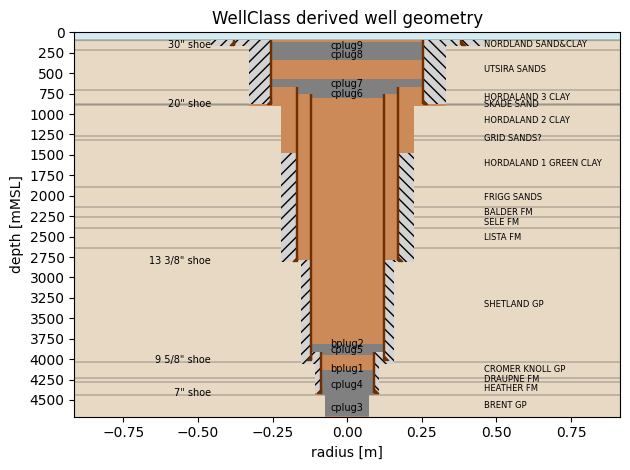

In [21]:
import matplotlib.pyplot as plt
from src.WellClass.libs.plotting.plot_sketch import plot_sketch

fig, ax = plot_sketch(processed_well, draw_open_hole=False)
ax.set_title('WellClass derived well geometry')
fig.tight_layout()
plt.show()

## One-page pressure and P-T quality control

In [ ]:
import numpy as np
from scipy import constants as const
from scipy.interpolate import RectBivariateSpline
from src.WellClass.libs.pvt.pvt import get_hydrostatic_P, get_pvt
from src.WellClass.libs.well_pressure.co2_pressure import _integrate_pressure

pvt_path = root / 'test_data/pvt_constants'
pvt_header = {
    **processed_well.header,
    'sf_depth_msl': processed_well.header['ground_elevation'],
    'sf_temp': 4.0,
    'geo_tgrad': 40.0,
}
hydrostatic = get_hydrostatic_P(pvt_header, pvt_path=str(pvt_path), dz=10)
temperatures, pressures, rho_co2, rho_brine = get_pvt(str(pvt_path))
get_rho_co2 = RectBivariateSpline(pressures, temperatures, rho_co2)
co2_datum = 2500.0
co2_pressure_at_datum = float(np.interp(co2_datum, hydrostatic['depth_msl'], hydrostatic['hs_p']))
co2_column = _integrate_pressure(
    well_header=pvt_header,
    pt_df_in=hydrostatic,
    get_rho=get_rho_co2,
    reference_depth=co2_datum,
    reference_pressure=co2_pressure_at_datum,
    direction='up',
    colname_p='co2',
)
co2_column = _integrate_pressure(
    well_header=pvt_header,
    pt_df_in=co2_column,
    get_rho=get_rho_co2,
    reference_depth=co2_datum,
    reference_pressure=co2_pressure_at_datum,
    direction='down',
    colname_p='co2',
)

fig, (ax_well, ax_pressure) = plt.subplots(1, 2, figsize=(12, 8), sharey=True)
plot_sketch(processed_well, ax=ax_well, draw_open_hole=True)
ax_well.set_title('WellClass sketch')

ax_pressure.plot(hydrostatic['hs_p'], hydrostatic['depth_msl'], color='steelblue', label='hydrostatic water')
ax_pressure.plot(co2_column['co2'], co2_column['depth_msl'], color='firebrick', label=f'CO2 column @ {co2_datum:.0f} mMSL')
ax_pressure.set_title('Pressure profiles')
ax_pressure.set_xlabel('pressure [bar]')
ax_pressure.set_ylabel('depth [mMSL]')
ax_pressure.set_ylim(0, max(hydrostatic['depth_msl']))
ax_pressure.invert_yaxis()
ax_pressure.grid(alpha=0.25)
ax_pressure.legend()
fig.suptitle('WellClass one-page QC')
fig.tight_layout()
plt.show()

NameError: name 'np' is not defined

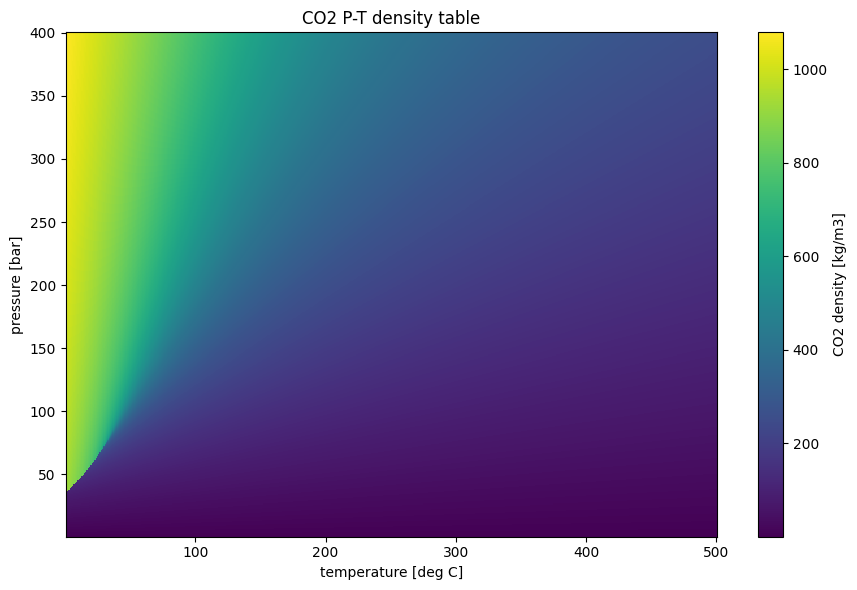

In [23]:
temperatures, pressures, rho_co2, rho_brine = get_pvt(str(pvt_path))

fig, ax = plt.subplots(figsize=(9, 6))
image = ax.pcolormesh(temperatures, pressures, rho_co2, shading='auto', cmap='viridis')
ax.set_title('CO2 P-T density table')
ax.set_xlabel('temperature [deg C]')
ax.set_ylabel('pressure [bar]')
fig.colorbar(image, ax=ax, label='CO2 density [kg/m3]')
fig.tight_layout()
plt.show()

In [24]:
assert len(processed_well.borehole) > 0
assert len(processed_well.annulus) > 0
assert all(row['bottom_rkb'] >= row['top_rkb'] for row in processed_well.borehole)
print('WellClass derivation checks passed')

WellClass derivation checks passed
